# Método de Euler para aproximar soluciones  de una ecuación diferencial

**Recordar método de Euler**

Suponga que queremos resolver numericamente el problema de valor inicial

$$\dfrac{d y(t)}{dt} = f(t,y), \quad \text{con } y(0) := c.$$

Utilizando el método de Euler podemos aproximar la función $y_i = y(t_i)$ evaluada en una sucesión de tiempos $t_{i}$ mediante la formula (diferencias finitas)

$$ y_{i+1} = y_{i} + f(t_i,y_i)  \  dt $$

donde $dt := t_{i+1} - t_{i}$





**Ejemplo**

Ciertos elementos (denominados radiactivos) son inestables y en un intervalo de tiempo dado, una fracción fija de átomos se desintegra espontáneamente formando así un nuevo elemento. El anterior fenómeno  se puede modelar mediante la siguiente ecuación diferencial 
$$ \dfrac{d N}{dt} = -\lambda N, $$
donde $N$ es la cantidad de átomos presentes de un cierto elemento, $\lambda$ es la constante (positiva) de decaimiento radiactivo y $t$ es el tiempo medido en segundos. Suponiendo que inicialmente se tenian $10^6$ atomos radiactivos y que la constante de decaimiento es de $0.05~\rm{s}^{-1}$, realice:
- Un gráfico de la función $N$ en el tiempo.
- Aproxime el número de átomos del elemento radiactivo que estarán presentes después de $4$ minutos. 

**Solución**

Usando un ciclo for:

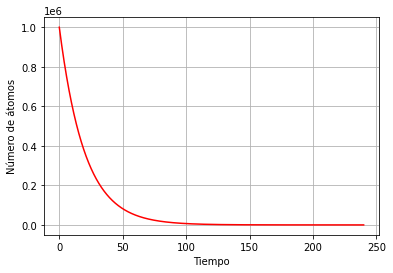

In [1]:
#importamos las librerias de numpy

import numpy as np
import matplotlib.pyplot as plt


Lambda = 0.05

#Defino la función
def f(t, y):
  return -Lambda * y

#PARAMETROS
t0 = 0
tf = 240 # Segundos equivalentes a 4 minutos!
dt = 0.001

#lista de tiempos  
t = np.arange(t0,tf,dt)

#Numero de tiempos
N = len(t)

#lista los valores de la función
y = np.zeros_like(t)

#asigno el valor inicial
y[0] =  10**6 

#Aplicamos la formula de Euler
for i in range( N-1 ):
    y[i+1] = y[i] +  dt* f(t[i],y[i])
    

plt.plot(t, y,'-r')
plt.grid()
plt.xlabel('Tiempo')
plt.ylabel('Número de átomos')
plt.show()

In [ ]:
#Valor en 4 minutos = 240 segundos!

print("El numero de atomos presente en 4 minutos es: ", y[-1])


El numero de atomos presente en 4 minutos es:  6.142676438480172


**Comparando con la solucion exacta**

La solución exacta del problema de la EDO es:

$$N = N_0 \ e^{-\lambda t}$$

Por lo tanto:

In [ ]:
def exacta(t):    
    return y[0] * np.exp(- Lambda * t)

Comparando los gráficos y obteniendo errores:

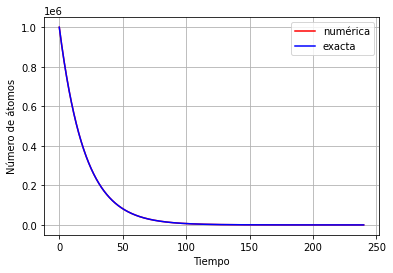

In [ ]:
plt.plot(t,         y,'-r', label='numérica')
plt.plot(t, exacta(t),'-b', label='exacta')
plt.grid()
plt.xlabel('Tiempo')
plt.ylabel('Número de átomos')
plt.legend()
plt.show()

- Calculando la diferencia

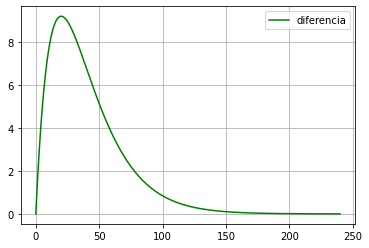

In [ ]:
plt.plot(t, np.abs( exacta(t) - y )  ,'-g', label='diferencia') 
plt.grid()
plt.legend()
plt.show()

- Mostrando la diferencia en escala logaritmica (es mas adecuado)

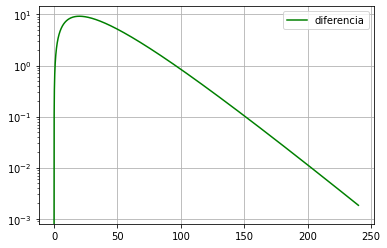

In [ ]:
plt.plot(t, np.abs( exacta(t) - y )  ,'-g', label='diferencia') 
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

Enfatice en el hecho de que el método de Euler es de orden $dt$ y la derivada de la función y por lo tanto depende del tamaño de estos (es fundamental tener idea de esto). Corra el grafico del error para varios valores de $dt$ y observe como se reduce la diferencia de la solución exacta con la numérica. Ademas, mencione que cuando la función decae lento, el método de Euler es bueno, pero no cuando la función decae rápido!....esto puede parecer algo técnico, pero es necesario que los estudiantes comprendan lo limitado de este método. Finalmente, comente que existen muchos otros métodos para tener mejores aproximaciones.






**Ejercicio (entregable de forma OPCIONAL)**

Realizar el mismo ejercicio utilizando un ciclo while partiendo del diagrama de flujo propuesto en clase. Esto estara en la carpeta compartida con los estudiantes de google collab.

**Nota:** Mostrar en clase el algoritmo del metodo de enviado por Karem. Se adjuntara a este archivo. 

### Ejemplo de sistemas de EDO (opcional en caso de quedar tiempo!)

Usando la fisica Newtoniana se obtiene la ecuación de movimiento del pendulo 

\begin{equation}
\dfrac{d^2 \theta}{d t^2} + \dfrac{g}{l}\sin\theta  = 0 .
\end{equation}

Esta ecuación es dificil de solucionar de forma exacta por que es NO lineal. Ademas, como es una ecuacion diferencial de segundo orden, tenemos que definir la nueva variable $\omega = \dfrac{d\theta}{d t}$ y asi obtenemos el sistema: 

\begin{eqnarray}
\dfrac{d \theta}{d t} &=& \omega, \\
\dfrac{d \omega}{d t} &=& -\dfrac{g}{l}\sin\theta.
\end{eqnarray}

Luego, podemos resolver este sistema de ecuaciones diferenciales ordinarias de primer orden con el metodo de Euler.


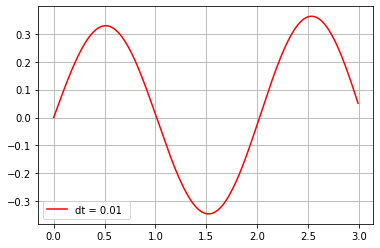

In [ ]:
import matplotlib.pyplot as plt

g  = 9.8
L  = 1

#dos condiciones por que es un sistema de segundo orden
theta0  = 0
omega0 = 1


#numero de pasos
dt = 0.01
tiempos= np.arange(0, 3, dt)


N_pasos = len(tiempos)
 

theta = np.zeros(N_pasos)
omega = np.zeros(N_pasos)


theta[0]  = theta0
omega[0] =  omega0

 
#Usando el metodo de Euler
for i in range( N_pasos-1 ): 
    theta[i+1]  =  theta[i] + dt * omega[i]  
    omega[i+1]  =  omega[i] + dt * (- (g/L)*np.sin(theta[i]) ) 
  

#graficando el movimiento del pendulo
plt.plot(tiempos,         theta,'-r', label='dt = 0.01 ')
plt.grid()
plt.legend()
plt.show()
    

- Repetir el programa con un $dt$ mas pequeño

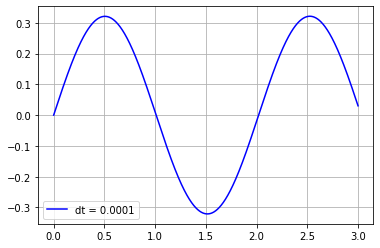

In [ ]:
import matplotlib.pyplot as plt

g  = 9.8
L  = 1

#dos condiciones por que es un sistema de segundo orden
theta0  = 0
omega0 = 1


#numero de pasos
dt = 0.0001
tiempos2= np.arange(0, 3, dt)


N_pasos = len(tiempos2)
 

theta2 = np.zeros(N_pasos)
omega2 = np.zeros(N_pasos)


theta2[0]  = theta0
omega2[0] =  omega0

 
#Usando el metodo de Euler
for i in range( N_pasos-1 ): 
    theta2[i+1]  =  theta2[i] + dt * omega2[i]  
    omega2[i+1]  =  omega2[i] + dt * (- (g/L)*np.sin(theta2[i]) ) 
  

#graficando el movimiento del pendulo
plt.plot(tiempos2,         theta2,'-b', label='dt = 0.0001')
plt.grid()
plt.legend()
plt.show()

- comparando los dos gráficos

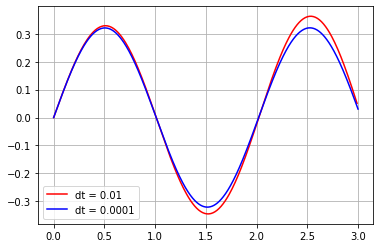

In [ ]:
plt.plot(tiempos , theta ,'-r', label='dt = 0.01')
plt.plot(tiempos2, theta2,'-b', label='dt = 0.0001')
plt.grid()
plt.legend()
plt.show()

**NOTA :** Comentar el porque de la diferencia entre los dos gráficos y enfatizar en el tamaño de paso.